In [ ]:
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install seaborn

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Limpieza de datos: Tratar valores faltantes, codificaciones extrañas y posibles errores.

In [2]:
# Read in the dataset
df = pd.read_csv('./car_sales_data.csv')
print(df.head())

         Date      Salesperson   Customer Name Car Make  Car Model  Car Year  \
0  2022-08-01  Monica Moore MD     Mary Butler   Nissan     Altima    2018.0   
1  2023-03-15     Roberto Rose  Richard Pierce   Nissan      F-150    2016.0   
2  2023-04-29     Ashley Ramos    Sandra Moore     Ford      Civic    2016.0   
3  2022-09-04   Patrick Harris    Johnny Scott     Ford     Altima    2013.0   
4  2022-06-16       Eric Lopez   Vanessa Jones    Honda  Silverado    2022.0   

   Sale Price  Commission Rate  Commission Earned  
0     15983.0         0.070495            1126.73  
1     38474.0         0.134439            5172.40  
2     33340.0         0.114536            3818.63  
3     41937.0         0.092191            3866.20  
4     20256.0         0.113490            2298.85  


In [3]:
#Información general del dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458981 entries, 0 to 1458980
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Date               1458981 non-null  object 
 1   Salesperson        1458980 non-null  object 
 2   Customer Name      1458980 non-null  object 
 3   Car Make           1458980 non-null  object 
 4   Car Model          1458980 non-null  object 
 5   Car Year           1458980 non-null  float64
 6   Sale Price         1458980 non-null  float64
 7   Commission Rate    1458980 non-null  float64
 8   Commission Earned  1458980 non-null  float64
dtypes: float64(4), object(5)
memory usage: 100.2+ MB
None


In [13]:
#Revisar valores faltantes por columna
print(df.isnull().sum())

Date                 0
Salesperson          0
Customer Name        0
Car Make             0
Car Model            0
Car Year             0
Sale Price           0
Commission Rate      0
Commission Earned    0
dtype: int64


In [5]:
df = df.dropna(subset=["Car Make", "Car Model", "Sale Price", "Car Year"])

In [6]:
print(df.isnull().sum())

Date                 0
Salesperson          0
Customer Name        0
Car Make             0
Car Model            0
Car Year             0
Sale Price           0
Commission Rate      0
Commission Earned    0
dtype: int64


In [ ]:
print(df["Car Make"].unique())
print(df["Sale Price"].unique())

2. Descripción de las variables y datos: Identificar los tipos, calcular estadísticos para sa-
ber cómo se distribuyen, rangos, e identificar valores atípicos o también conocidos
como outliers.

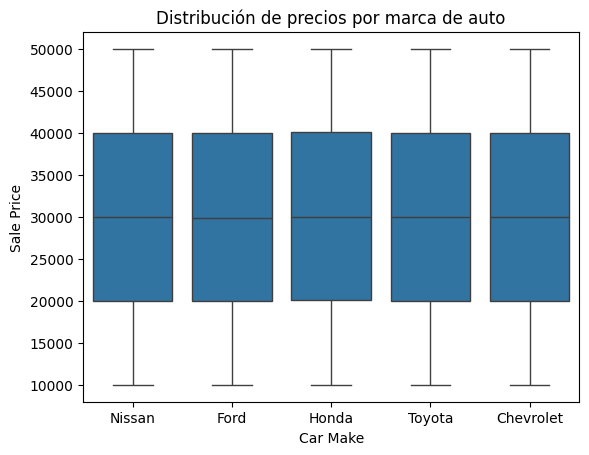

In [7]:
sns.boxplot(x="Car Make", y="Sale Price", data=df)
plt.title("Distribución de precios por marca de auto")
plt.show()

In [26]:
#q_low = df["Sale Price"].quantile(0.01)
#q_high = df["Sale Price"].quantile(0.99)
#df = df[(df["Sale Price"] >= q_low) & (df["Sale Price"] <= q_high)]

In [8]:
print("Tamaño del dataset limpio:", df.shape)

Tamaño del dataset limpio: (1458980, 9)


In [9]:
print("\nEstadísticos descriptivos de variables numéricas:")
print(df[["Sale Price", "Commission Earned"]].describe())


Estadísticos descriptivos de variables numéricas:
         Sale Price  Commission Earned
count  1.458980e+06       1.458980e+06
mean   3.001313e+04       3.001200e+03
std    1.154187e+04       1.481279e+03
min    1.000000e+04       5.013400e+02
25%    2.002400e+04       1.822160e+03
50%    3.000300e+04       2.742180e+03
75%    4.002100e+04       3.979360e+03
max    5.000000e+04       7.494530e+03


In [10]:
print("\nFrecuencia de los modelos más comunes:")
print(df["Car Model"].value_counts().head(10))

print("\nFrecuencia de las marcas más comunes:")
print(df["Car Make"].value_counts())


Frecuencia de los modelos más comunes:
Car Model
Silverado    292626
Civic        291988
Corolla      291722
F-150        291421
Altima       291223
Name: count, dtype: int64

Frecuencia de las marcas más comunes:
Car Make
Honda        292212
Ford         292063
Chevrolet    292055
Toyota       291493
Nissan       291157
Name: count, dtype: int64


In [11]:
print("\nRango de precios:")
print("Mínimo:", df["Sale Price"].min())
print("Máximo:", df["Sale Price"].max())

print("\nRango de anios vendidos:")
print("Mínimo:", df["Car Year"].min())
print("Máximo:", df["Car Year"].max())


Rango de precios:
Mínimo: 10000.0
Máximo: 50000.0

Rango de anios vendidos:
Mínimo: 2010.0
Máximo: 2022.0


In [12]:
Q1 = df["Sale Price"].quantile(0.25)
Q3 = df["Sale Price"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Sale Price"] < Q1 - 1.5*IQR) | (df["Sale Price"] > Q3 + 1.5*IQR)]
print("\nCantidad de outliers en Precio:", outliers.shape[0])


Cantidad de outliers en Precio: 0


In [ ]:
Descripcion de las variables y datos:
-Identifica cuales son numericas y cuales son categoricas
-Estadistico descriptivo para variables numericas
-Estadistico descriptivo para variables categoricas

In [24]:
print("Tipos de variables en el DataFrame:")
print(df.dtypes)

Tipos de variables en el DataFrame:
Date                  object
Salesperson           object
Customer Name         object
Car Make              object
Car Model             object
Car Year             float64
Sale Price           float64
Commission Rate      float64
Commission Earned    float64
dtype: object


3. Visualizaciones: Realizar gráficos que ayuden a comprender tendencias, relaciones,
diferencias, agrupamientos y otros comportamientos presentes en los datos.

In [ ]:
#Estadisticos descriptivos, solo para variables numericas
pd.set_option("display.float_format", "{:,.2f}".format) #fuerza a mostrar los numeros con 2 decimales
print("\nEstadisticos descriptivos de variables numericas:")
print(df.describe())

In [ ]:
#Estadisticos descriptivos para variables categoricas
print("\nEstadisticos descriptivos de variables categoricas:")
print(df.describe(include=['object', 'category']))

In [ ]:
#Distribución de precios
plt.figure(figsize=(8,5))
sns.histplot(df["Sale Price"], bins=50, kde=True)
plt.title("Distribución de precios de venta")
plt.xlabel("Precio de venta")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
#Boxplot de precio por año
plt.figure(figsize=(10,5))
sns.boxplot(x="Car Year", y="Sale Price", data=df)
plt.title("Precio de venta según año del vehículo")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Top 10 marcas más vendidas
top_makes = df["Car Make"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_makes.index, y=top_makes.values)
plt.title("Top 10 marcas más registradas en ventas")
plt.xlabel("Marca")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.show()

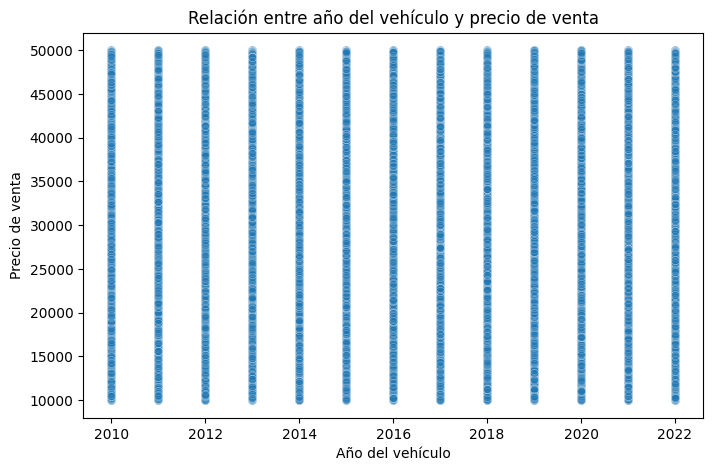

In [43]:
#Relación entre precio y año
plt.figure(figsize=(8,5))
sns.scatterplot(x="Car Year", y="Sale Price", data=df, alpha=0.3)
plt.title("Relación entre año del vehículo y precio de venta")
plt.xlabel("Año del vehículo")
plt.ylabel("Precio de venta")
plt.show()

In [ ]:
#Modelos más frecuentes
top_models = df["Car Model"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_models.index, y=top_models.values)
plt.title("Top 10 modelos más frecuentes en ventas")
plt.xlabel("Modelo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)

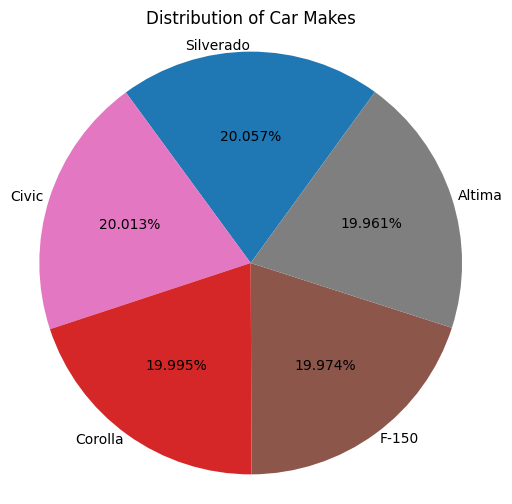

In [42]:
#Get value counts for car makes
car_model_counts = df['Car Model'].value_counts()
slices = [62, 39, 39, 38, 37, 21, 15,  9,  6,  7,  6,  5,  4, 3]
cmap = plt.cm.prism
colors = cmap(np.linspace(0., 1., len(slices)))
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(car_model_counts, labels=car_model_counts.index, labeldistance=1.03, autopct='%1.3f%%', startangle=54, colors=['C0', 'C6', 'C3', 'C5', 'C7'])
ax.axis('equal')
ax.set_title('Distribution of Car Makes')

plt.show()

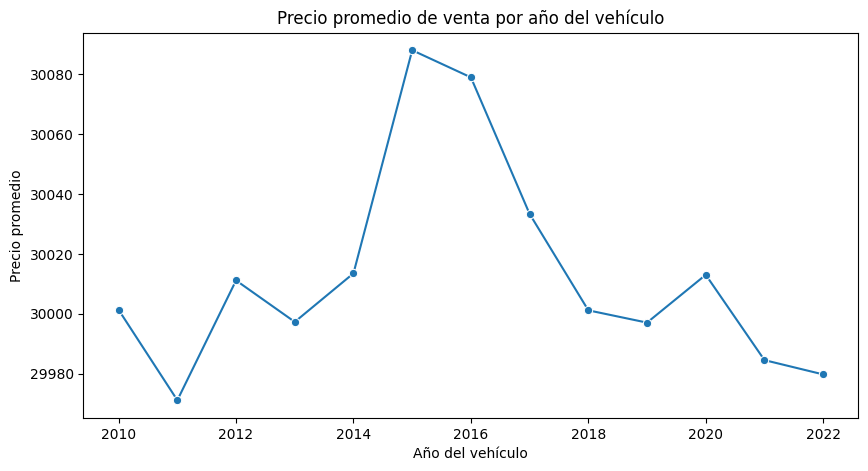

In [44]:
avg_prices = df.groupby("Car Year")["Sale Price"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_prices.index, y=avg_prices.values, marker="o")
plt.title("Precio promedio de venta por año del vehículo")
plt.xlabel("Año del vehículo")
plt.ylabel("Precio promedio")
plt.show()

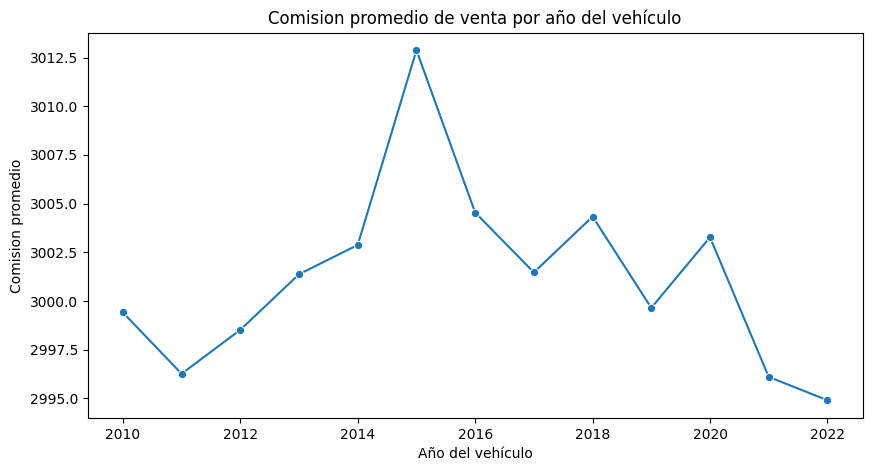

In [49]:
avg_comission = df.groupby("Car Year")["Commission Earned"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_comission.index, y=avg_comission.values, marker="o")
plt.title("Comision promedio de venta por año del vehículo")
plt.xlabel("Año del vehículo")
plt.ylabel("Comision promedio")
plt.show()

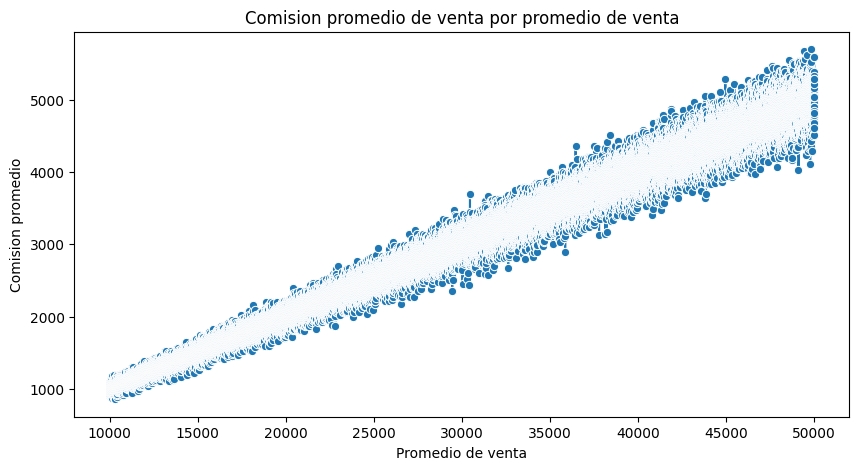

In [54]:

avg_comission = df.groupby("Sale Price")["Commission Earned"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_comission.index, y=avg_comission.values, marker="o")
plt.title("Comision promedio de venta por promedio de venta")
plt.xlabel("Promedio de venta")
plt.ylabel("Comision promedio")
plt.show()

4.Observar con lupa: Realizarse las siguientes preguntas ¿qué patrones saltan a la vista?
¿qué cosas no esperabas? ¿hay alguna relación interesante? La profundidad del análisis es muy importante para ser capaces de plantear 
una buena pregunta o hipótesis de investigación.
    

Al analizar las variables Sale Price y Commission Earned, se observa un patrón claro: las comisiones tienden a aumentar a medida que lo hace el precio de venta de los vehículos. Este comportamiento es esperado, ya que las comisiones suelen calcularse como un porcentaje del valor de la transacción. Sin embargo, se encontraron casos particulares de autos con precios elevados y comisiones relativamente bajas, lo cual resulta inesperado y sugiere la influencia de la tasa de comisión aplicada en cada venta.

2.4 Teniendo ambos graficos, podemos plantear la siguiente hipotesis: 
Que el promedio de venta tiene relacion a la comision promedio.

A partir del análisis realizado, podemos concluir que existe una relación directa entre el precio de venta de los vehículos y la comisión promedio obtenida. Esto significa que, en general, a mayor valor de venta, mayor es la comisión asociada, lo cual tiene sentido dado que las comisiones suelen calcularse como un porcentaje del precio del auto. Si bien se detectaron algunos casos particulares donde esta relación no se cumple del todo, la tendencia general confirma nuestra hipótesis: el promedio de venta está positivamente relacionado con la comisión promedio.